In [1]:
!pip install ultralytics
!pip install torch torchvision
!pip install numpy pandas matplotlib seaborn scikit-learn
!pip install opencv-python pillow tqdm pyyaml
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 122.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
import os, sys, glob, shutil, random, warnings, yaml, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision
import torchvision.transforms as transforms
from torchvision import models

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score,
                             ConfusionMatrixDisplay)
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
DEVICE = torch.device('cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device in use   : {DEVICE}")

PyTorch version : 2.10.0+cu128
Device in use   : cpu


### Dataset Download And Structure

In [5]:
from ultralytics.utils.downloads import download

url = "https://ultralytics.com/assets/brain-tumor.zip"
DATA_ROOT = Path("brain_tumor_dataset")
DATA_ROOT.mkdir(exist_ok=True)

download(url, dir=DATA_ROOT)
print("Download complete. Listing contents:")
for p in sorted(DATA_ROOT.rglob("*"))[:30]:
    print(" ", p)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Unzipping brain_tumor_dataset/brain-tumor.zip to /content/brain_tumor_dataset/brain-tumor...: 100% ━━━━━━━━━━━━ 2225/2225 8.9Kfiles/s 0.2s
Download complete. Listing contents:
  brain_tumor_dataset/brain-tumor
  brain_tumor_dataset/brain-tumor/LICENSE.txt
  brain_tumor_dataset/brain-tumor/brain-tumor.yaml
  brain_tumor_dataset/brain-tumor/images
  brain_tumor_dataset/brain-tumor/images/train
  brain_tumor_dataset/brain-tumor/images/train/00054_145.jpg
  brain_tumor_dataset/brain-tumor/images/train/00054_164.jpg
  brain_tumor_dataset/brain-tumor/images/train/00056_110.jpg
  brain_tumor_dataset/brain-tumor/images/train/00056_129.jpg
  brain_tumor_dataset/brain-tumor/images/train/000

In [6]:
SPLITS = ['train', 'val', 'test']

IMG_DIRS = {}
LBL_DIRS = {}

for split in SPLITS:
    img_path = DATA_ROOT / "brain-tumor" / "images" / split
    lbl_path = DATA_ROOT / "brain-tumor" / "labels" / split
    if img_path.exists():
        IMG_DIRS[split] = img_path
        LBL_DIRS[split] = lbl_path
        imgs = list(img_path.glob("*.jpg")) + list(img_path.glob("*.png"))
        print(f"[{split:>5}] images: {len(imgs):4d}  |  labels dir exists: {lbl_path.exists()}")
    else:
        print(f"[{split}] Not found — will create split manually.")

[train] images:  893  |  labels dir exists: True
[  val] images:  223  |  labels dir exists: True
[test] Not found — will create split manually.


We probe for the standard YOLO directory tree. If any split is missing (common with smaller datasets), we'll create it programmatically in the next cell.

Here, we didn't have Test. so we will created that from the Val inself.

In [7]:
import os, shutil, random
from pathlib import Path

random.seed(42)

# ── Update these paths to match YOUR actual structure ────────
BASE      = Path("brain_tumor_dataset/brain-tumor")
IMG_VAL   = BASE / "images" / "val"
LBL_VAL   = BASE / "labels" / "val"
IMG_TEST  = BASE / "images" / "test"
LBL_TEST  = BASE / "labels" / "test"

# Create test directories
IMG_TEST.mkdir(parents=True, exist_ok=True)
LBL_TEST.mkdir(parents=True, exist_ok=True)

# Gather all val images
val_images = sorted(list(IMG_VAL.glob("*.jpg")) + list(IMG_VAL.glob("*.png")))
random.shuffle(val_images)

# 50% of val → test
n_test = len(val_images) // 2
test_images = val_images[:n_test]

print(f"Total val images    : {len(val_images)}")
print(f"Moving to test      : {len(test_images)}")
print(f"Remaining in val    : {len(val_images) - len(test_images)}")

# Move images + their labels to test/
for img_path in test_images:
    # Move image
    shutil.move(str(img_path), str(IMG_TEST / img_path.name))

    # Move corresponding label (same stem, .txt extension)
    lbl_path = LBL_VAL / (img_path.stem + ".txt")
    if lbl_path.exists():
        shutil.move(str(lbl_path), str(LBL_TEST / lbl_path.name))
    else:
        print(f"  ⚠️  No label found for {img_path.name}")

print("\n✅ Done! New structure:")
for split in ['train', 'val', 'test']:
    n_img = len(list((BASE / "images" / split).glob("*.jpg"))) + \
            len(list((BASE / "images" / split).glob("*.png")))
    n_lbl = len(list((BASE / "labels" / split).glob("*.txt")))
    print(f"  [{split:>5}]  images: {n_img}  labels: {n_lbl}")

Total val images    : 223
Moving to test      : 111
Remaining in val    : 112

✅ Done! New structure:
  [train]  images: 893  labels: 878
  [  val]  images: 112  labels: 112
  [ test]  images: 111  labels: 111


In [8]:
import yaml

yaml_path = BASE / "brain-tumor.yaml"

# Read existing yaml first to preserve class names
with open(yaml_path) as f:
    existing = yaml.safe_load(f)

print("Existing YAML content:")
print(existing)

# Update with test split
new_yaml = {
    'path'  : str(BASE.resolve()),
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',       # ← newly added
    'nc'    : existing.get('nc', 2),
    'names' : existing.get('names', ['negative', 'positive'])
}

with open(yaml_path, 'w') as f:
    yaml.dump(new_yaml, f, default_flow_style=False)

print("\n✅ Updated YAML:")
print(open(yaml_path).read())

Existing YAML content:
{'path': 'brain-tumor', 'train': 'images/train', 'val': 'images/val', 'test': None, 'names': {0: 'negative', 1: 'positive'}, 'download': 'https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip'}

✅ Updated YAML:
names:
  0: negative
  1: positive
nc: 2
path: /content/brain_tumor_dataset/brain-tumor
test: images/test
train: images/train
val: images/val



In [9]:
# ── Correct paths matching YOUR folder structure ─────────────
DATA_ROOT = Path("brain_tumor_dataset/brain-tumor")

IMG_DIRS = {
    'train' : DATA_ROOT / "images" / "train",
    'val'   : DATA_ROOT / "images" / "val",
    'test'  : DATA_ROOT / "images" / "test",   # now exists after split
}
LBL_DIRS = {
    'train' : DATA_ROOT / "labels" / "train",
    'val'   : DATA_ROOT / "labels" / "val",
    'test'  : DATA_ROOT / "labels" / "test",   # now exists after split
}

yaml_path = DATA_ROOT / "brain-tumor.yaml"

SPLITS = ['train', 'val', 'test']

# Verify
for split in SPLITS:
    n = len(list(IMG_DIRS[split].glob("*.jpg"))) + \
        len(list(IMG_DIRS[split].glob("*.png")))
    print(f"[{split}] {n} images")

[train] 893 images
[val] 112 images
[test] 111 images


We're using test as separately, because val was seen during the training.

## EDA

In [10]:
CLASS_NAMES = {0: 'negative', 1: 'positive'}  # brain tumor absent / present

records = []
for split in SPLITS:
    lbl_dir = LBL_DIRS.get(split)
    img_dir = IMG_DIRS.get(split)
    if lbl_dir is None:
        continue
    for lbl_file in lbl_dir.glob("*.txt"):
        img_file = img_dir / lbl_file.with_suffix('.jpg').name
        if not img_file.exists():
            img_file = img_dir / lbl_file.with_suffix('.png').name
        # read image dimensions
        try:
            w, h = Image.open(img_file).size
        except Exception:
            w, h = 0, 0

        with open(lbl_file) as f:
            lines = f.read().strip().splitlines()

        if not lines or lines == ['']:
            # background image — no tumor
            records.append({'split': split, 'class_id': -1, 'class_name': 'no_annotation',
                            'cx': None, 'cy': None, 'bw': None, 'bh': None,
                            'img_w': w, 'img_h': h, 'img_file': str(img_file)})
        else:
            for line in lines:
                parts = line.split()
                cls = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                records.append({'split': split, 'class_id': cls,
                                'class_name': CLASS_NAMES.get(cls, f'class_{cls}'),
                                'cx': cx, 'cy': cy, 'bw': bw, 'bh': bh,
                                'img_w': w, 'img_h': h, 'img_file': str(img_file)})

df = pd.DataFrame(records)
print(f"Total annotation records: {len(df)}")
print(df.head(8))

Total annotation records: 1166
   split  class_id class_name        cx        cy        bw        bh  img_w  \
0  train         1   positive  0.440728  0.156103  0.109155  0.157277    512   
1  train         0   negative  0.367371  0.271714  0.169014  0.120892    512   
2  train         1   positive  0.649452  0.592723  0.073552  0.063380    192   
3  train         1   positive  0.623239  0.470657  0.147887  0.154930    512   
4  train         1   positive  0.474178  0.271714  0.112676  0.127934    512   
5  train         1   positive  0.610915  0.281690  0.156103  0.147887    512   
6  train         1   positive  0.629108  0.118545  0.133803  0.129108    512   
7  train         1   positive  0.658451  0.353286  0.119718  0.185446    512   

   img_h                                           img_file  
0    512  brain_tumor_dataset/brain-tumor/images/train/8...  
1    512  brain_tumor_dataset/brain-tumor/images/train/6...  
2    256  brain_tumor_dataset/brain-tumor/images/train/0...  


We parse every label file into a tidy DataFrame — this is the single most useful data structure for EDA. Each row is one bounding-box annotation; images with no boxes get a sentinel row so we don't silently lose them.

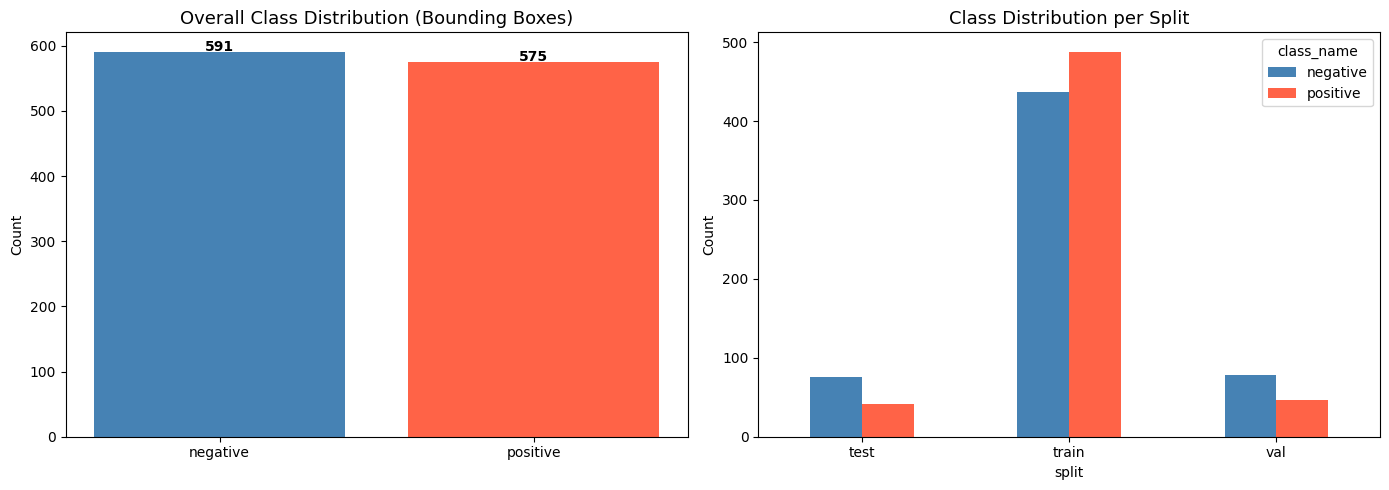

class_name
negative    591
positive    575
Name: count, dtype: int64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
counts = df[df.class_id >= 0]['class_name'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Overall Class Distribution (Bounding Boxes)', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Per split
split_counts = (df[df.class_id >= 0]
                .groupby(['split', 'class_name'])
                .size()
                .unstack(fill_value=0))
split_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Class Distribution per Split', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=120)
plt.show()
print(counts)

Class imbalance is the #1 EDA finding in medical imaging. If positive (tumor) samples are rare, we must compensate during training (weighted loss or oversampling). The split-wise chart confirms the split preserves class ratios.

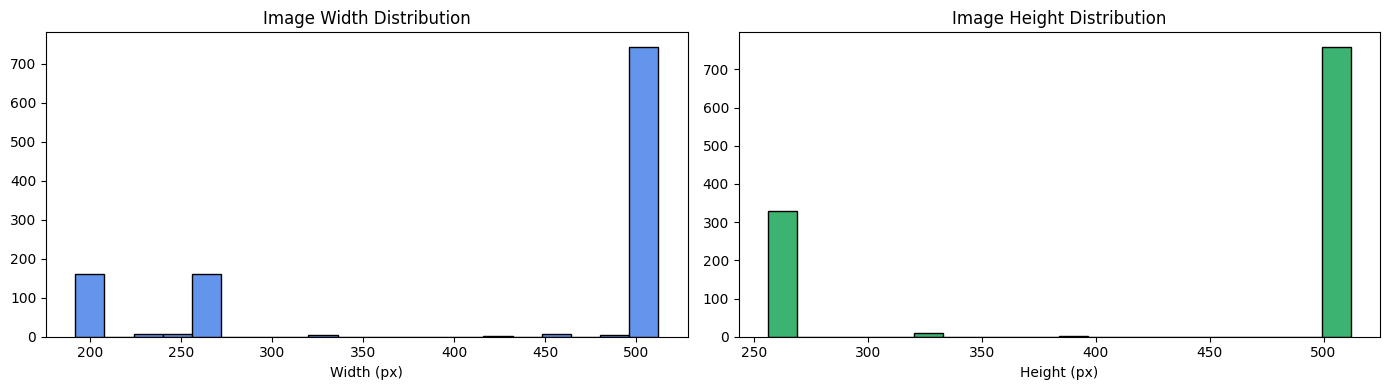

        img_w   img_h
count  1101.0  1101.0
mean    422.2   433.4
std     133.5   117.5
min     192.0   256.0
25%     256.0   256.0
50%     512.0   512.0
75%     512.0   512.0
max     512.0   512.0


In [12]:
valid_df = df[df.img_w > 0].drop_duplicates('img_file')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(valid_df['img_w'], bins=20, color='cornflowerblue', edgecolor='k')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')

axes[1].hist(valid_df['img_h'], bins=20, color='mediumseagreen', edgecolor='k')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')

plt.tight_layout()
plt.savefig('eda_image_sizes.png', dpi=120)
plt.show()

print(valid_df[['img_w', 'img_h']].describe().round(1))

Most YOLO models expect square inputs (e.g., 640*640). Knowing the native resolution guides our choice of resize strategy and whether padding will distort many images.

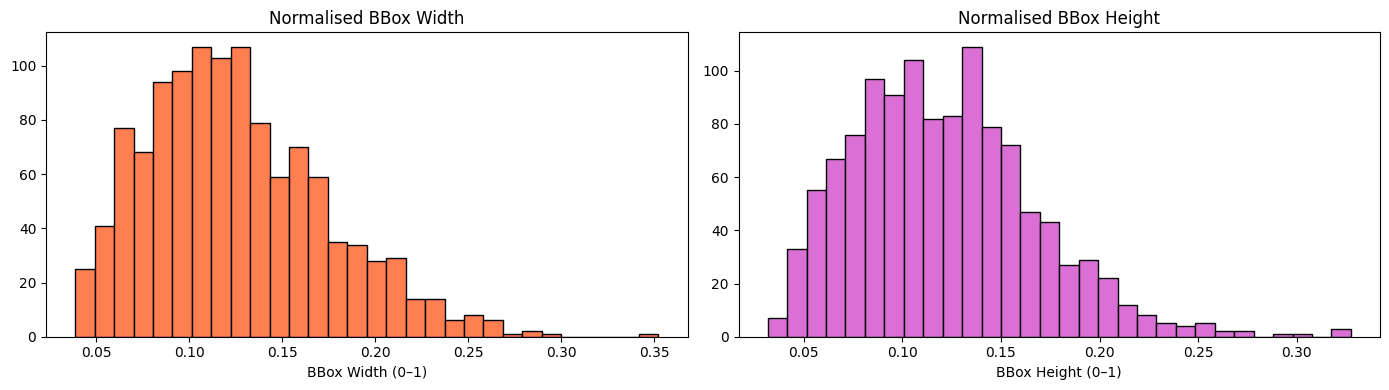

In [13]:
bb_df = df[df.bw.notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(bb_df['bw'], bins=30, color='coral', edgecolor='k')
axes[0].set_title('Normalised BBox Width')
axes[0].set_xlabel('BBox Width (0–1)')

axes[1].hist(bb_df['bh'], bins=30, color='orchid', edgecolor='k')
axes[1].set_title('Normalised BBox Height')
axes[1].set_xlabel('BBox Height (0–1)')

plt.tight_layout()
plt.savefig('eda_bbox_sizes.png', dpi=120)
plt.show()

If tumors are very small (bw, bh < 0.1), small-object detection strategies (higher input resolution, anchor tuning) become important.

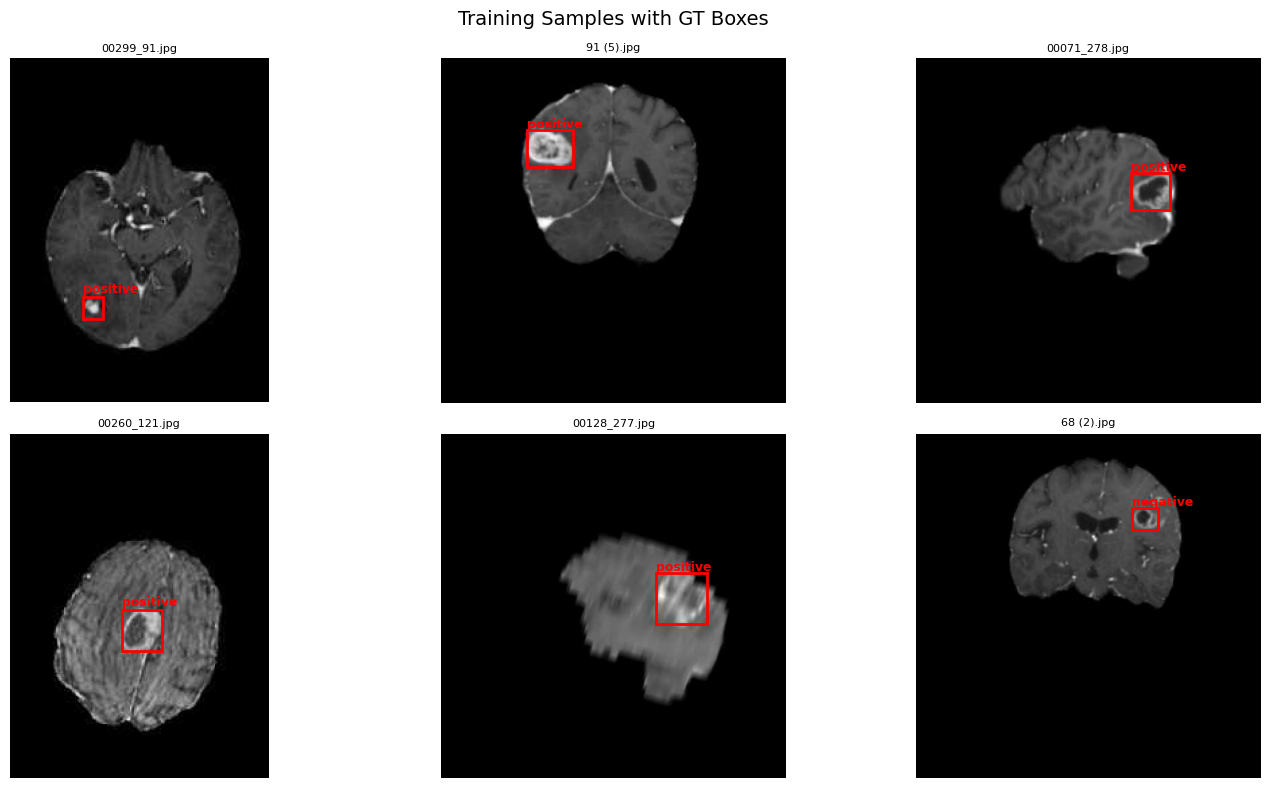

In [14]:
def show_samples(img_dir, lbl_dir, n=6, title="Sample Images"):
    img_files = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    random.shuffle(img_files)
    img_files = img_files[:n]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(title, fontsize=14)

    for ax, img_path in zip(axes.flatten(), img_files):
        img = np.array(Image.open(img_path).convert('RGB'))
        H, W = img.shape[:2]
        ax.imshow(img)

        lbl_path = lbl_dir / img_path.with_suffix('.txt').name
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f.read().strip().splitlines():
                    if not line:
                        continue
                    cls, cx, cy, bw, bh = map(float, line.split()[:5])
                    x1 = (cx - bw/2) * W
                    y1 = (cy - bh/2) * H
                    rect = patches.Rectangle(
                        (x1, y1), bw*W, bh*H,
                        linewidth=2, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 4, CLASS_NAMES.get(int(cls), str(int(cls))),
                            color='red', fontsize=9, fontweight='bold')
        ax.axis('off')
        ax.set_title(img_path.name[:20], fontsize=8)

    plt.tight_layout()
    plt.savefig('eda_samples.png', dpi=120)
    plt.show()

show_samples(IMG_DIRS['train'], LBL_DIRS['train'], n=6, title="Training Samples with GT Boxes")

Visual inspection catches label errors (wrong class, wildly off-center boxes) that summary statistics miss. Red rectangles show ground-truth tumour regions.

In [15]:
print("="*55)
print("           EDA SUMMARY")
print("="*55)
for split in SPLITS:
    sub = df[df.split == split]
    unique_imgs = sub['img_file'].nunique()
    n_pos = (sub.class_id == 1).sum()
    n_neg = (sub.class_id == 0).sum()
    print(f"\n[{split}]  images={unique_imgs}  positive_boxes={n_pos}  negative_boxes={n_neg}")

print(f"\nImage widths  — mean: {valid_df.img_w.mean():.0f}px  std: {valid_df.img_w.std():.0f}px")
print(f"Image heights — mean: {valid_df.img_h.mean():.0f}px  std: {valid_df.img_h.std():.0f}px")
print(f"BBox area (w×h) — mean: {(bb_df.bw * bb_df.bh).mean():.4f}  min: {(bb_df.bw * bb_df.bh).min():.4f}")

           EDA SUMMARY

[train]  images=878  positive_boxes=488  negative_boxes=437

[val]  images=112  positive_boxes=46  negative_boxes=78

[test]  images=111  positive_boxes=41  negative_boxes=76

Image widths  — mean: 422px  std: 134px
Image heights — mean: 433px  std: 118px
BBox area (w×h) — mean: 0.0169  min: 0.0013


## CNN from Scratch

In [16]:
# CELL 4.1 — Build Image-Level Classification Labels
# For each image, label = 1 if any 'positive' (class_id==1) annotation exists

def build_clf_dataset(img_dir, lbl_dir):
    """Returns list of (img_path, label) tuples."""
    data = []
    for img_path in sorted(img_dir.glob("*.jpg")) + sorted(img_dir.glob("*.png")):
        lbl_path = lbl_dir / img_path.with_suffix('.txt').name
        label = 0  # default: no tumor
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f.read().strip().splitlines():
                    if line and int(line.split()[0]) == 1:
                        label = 1
                        break
        data.append((str(img_path), label))
    return data

train_data = build_clf_dataset(IMG_DIRS['train'], LBL_DIRS['train'])
val_data   = build_clf_dataset(IMG_DIRS['val'],   LBL_DIRS['val'])
test_data  = build_clf_dataset(IMG_DIRS['test'],  LBL_DIRS['test'])

print(f"Train : {len(train_data)}  |  Val : {len(val_data)}  |  Test : {len(test_data)}")
train_labels = [l for _, l in train_data]
print(f"Train class dist: {Counter(train_labels)}")

Train : 893  |  Val : 112  |  Test : 111
Train class dist: Counter({1: 459, 0: 434})


YOLO bounding-box datasets don't natively provide image-level classification labels, so we derive them: if at least one tumour box exists in an image -> label=1. This bridges the detection dataset to our CNN classification task.

In [17]:
IMG_SIZE = 224   # keep small for CPU speed; increase to 224 if time permits

class BrainTumorDataset(Dataset):
    def __init__(self, data, transform=None):
        """
        data : list of (img_path_str, label) tuples
        transform : torchvision transforms
        """
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ── Transforms ───
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Loaders ───
BATCH_SIZE = 16  # small batch — CPU friendly

train_ds = BrainTumorDataset(train_data, train_tf)
val_ds   = BrainTumorDataset(val_data,   val_tf)
test_ds  = BrainTumorDataset(test_data,  val_tf)

# Handle class imbalance with WeightedRandomSampler
class_counts = Counter(train_labels)
weights = [1.0 / class_counts[l] for _, l in train_data]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches per epoch — train: {len(train_loader)}  val: {len(val_loader)}")

Batches per epoch — train: 56  val: 7


ImageNet normalisation is used even for a scratch model — it's a safe default that keeps pixel values centred.

WeightedRandomSampler oversamples the minority class each epoch, preventing the model from simply predicting the majority class.

Augmentation (flips, rotation, colour jitter) artificially expands a small dataset, reducing overfitting.

In [18]:
# CELL 4.3 — CNN Architecture

class BrainTumorCNN(nn.Module):
    """
    Lightweight 3-block CNN for binary brain tumour classification.

    Architecture:
      Block 1: Conv(3→32) → BN → ReLU → Conv(32→32) → BN → ReLU → MaxPool → Dropout
      Block 2: Conv(32→64) → BN → ReLU → Conv(64→64) → BN → ReLU → MaxPool → Dropout
      Block 3: Conv(64→128) → BN → ReLU → Conv(128→128) → BN → ReLU → AdaptiveAvgPool
      Classifier: FC(128→64) → ReLU → Dropout → FC(64→2)

    Rationale:
      • Doubling filters each block follows the VGG convention, allowing
        progressively richer feature extraction.
      • BatchNorm stabilises training on CPU (no BN momentum issues).
      • AdaptiveAvgPool makes the classifier independent of input size.
      • Dropout(0.4) reduces co-adaptation of neurons (regularisation).
    """
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()

        def conv_block(in_ch, out_ch, pool=True):
            layers = [
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool2d(2))
            layers.append(nn.Dropout2d(dropout / 2))
            return nn.Sequential(*layers)

        self.block1 = conv_block(3,   32)
        self.block2 = conv_block(32,  64)
        self.block3 = conv_block(64, 128, pool=False)
        self.gap     = nn.AdaptiveAvgPool2d(1)   # Global Average Pooling

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)

    def feature_vector(self, x):
        """Returns 128-d embedding before classifier — used in ensemble."""
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return x.view(x.size(0), -1)


model_cnn = BrainTumorCNN(num_classes=2).to(DEVICE)
print(model_cnn)
total_params = sum(p.numel() for p in model_cnn.parameters())
print(f"\nTotal parameters: {total_params:,}")

BrainTumorCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=

 The architecture has ~450K parameters — large enough to learn meaningful tumour features. The feature_vector method will be reused in the ensemble section.

In [19]:
# Compute class weights for CrossEntropy to handle imbalance
neg_count = class_counts[0]
pos_count = class_counts[1]
total     = neg_count + pos_count
cw = torch.tensor([total / (2 * neg_count),
                    total / (2 * pos_count)], dtype=torch.float)

criterion = nn.CrossEntropyLoss(weight=cw)
optimizer = optim.Adam(model_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3)

print("Loss     :", criterion)
print("Optimiser:", optimizer)
print("Class weights:", cw)

Loss     : CrossEntropyLoss()
Optimiser: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Class weights: tensor([1.0288, 0.9728])


CrossEntropyLoss with inverse-frequency class weights penalises misclassifying the rare class (positive) more heavily. ReduceLROnPlateau halves the learning rate when validation accuracy stops improving — a simple but powerful scheduler that works well on CPU where training time is precious.

In [20]:
# CELL 4.5 — Training & Validation Loop

import torch
from sklearn.metrics import f1_score

# ------------------------------------------------
# Setup GPU
# ------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))

# Move model to GPU
model_cnn = model_cnn.to(DEVICE)

# ⭐ IMPORTANT FIX (prevents your error)
criterion = criterion.to(DEVICE)

# Faster GPU performance
torch.backends.cudnn.benchmark = True


# ------------------------------------------------
# Training Function
# ------------------------------------------------
def run_epoch(model, loader, criterion, optimizer, is_train, device):

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:

        for imgs, labels in loader:

            # Move to GPU
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(dim=1)

            total_loss += loss.item() * imgs.size(0)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    avg_loss = total_loss / total
    acc = correct / total

    f1 = f1_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    return avg_loss, acc, f1


# ------------------------------------------------
# Training Settings
# ------------------------------------------------

EPOCHS = 20   # Fast on T4 GPU

history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'train_f1': [],
    'val_f1': []
}

best_val_f1 = 0.0
best_weights = None


print(f"{'Epoch':>5} | {'Tr-Loss':>8} | {'Tr-Acc':>7} | {'Tr-F1':>6} | "
      f"{'Va-Loss':>8} | {'Va-Acc':>7} | {'Va-F1':>6}")

print("-" * 65)


# ------------------------------------------------
# Training Loop
# ------------------------------------------------

for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_acc, tr_f1 = run_epoch(
        model_cnn,
        train_loader,
        criterion,
        optimizer,
        True,
        DEVICE
    )

    va_loss, va_acc, va_f1 = run_epoch(
        model_cnn,
        val_loader,
        criterion,
        optimizer,
        False,
        DEVICE
    )

    scheduler.step(va_f1)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)

    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    history['train_f1'].append(tr_f1)
    history['val_f1'].append(va_f1)


    # Save Best Model
    if va_f1 > best_val_f1:

        best_val_f1 = va_f1

        best_weights = {
            k: v.clone()
            for k, v in model_cnn.state_dict().items()
        }

        print(
            f"{epoch:>5} | {tr_loss:>8.4f} | {tr_acc:>7.4f} | {tr_f1:>6.4f} | "
            f"{va_loss:>8.4f} | {va_acc:>7.4f} | {va_f1:>6.4f}  ← best"
        )

    else:

        print(
            f"{epoch:>5} | {tr_loss:>8.4f} | {tr_acc:>7.4f} | {tr_f1:>6.4f} | "
            f"{va_loss:>8.4f} | {va_acc:>7.4f} | {va_f1:>6.4f}"
        )


# ------------------------------------------------
# Load Best Model
# ------------------------------------------------

model_cnn.load_state_dict(best_weights)

torch.save(model_cnn.state_dict(), 'best_cnn.pth')

print("\nBest Val F1:", round(best_val_f1,4))
print("Weights saved to best_cnn.pth")

Using Device: cuda
GPU Name: Tesla T4
Epoch |  Tr-Loss |  Tr-Acc |  Tr-F1 |  Va-Loss |  Va-Acc |  Va-F1
-----------------------------------------------------------------
    1 |   0.6988 |  0.5006 | 0.4254 |   0.6808 |  0.6339 | 0.3880  ← best
    2 |   0.6936 |  0.5039 | 0.4984 |   0.7036 |  0.3929 | 0.3583
    3 |   0.6919 |  0.4983 | 0.4889 |   0.6820 |  0.6339 | 0.3880
    4 |   0.6982 |  0.5252 | 0.5249 |   0.7002 |  0.3750 | 0.3499
    5 |   0.6928 |  0.5286 | 0.4951 |   0.6792 |  0.6339 | 0.3880
    6 |   0.6854 |  0.5442 | 0.5419 |   0.7142 |  0.4107 | 0.3714
    7 |   0.6939 |  0.4961 | 0.4692 |   0.6871 |  0.5089 | 0.4240  ← best
    8 |   0.6877 |  0.5263 | 0.5221 |   0.6882 |  0.4821 | 0.3974
    9 |   0.6767 |  0.5689 | 0.5684 |   0.7185 |  0.3839 | 0.3328
   10 |   0.6868 |  0.5330 | 0.5329 |   0.7432 |  0.3661 | 0.2680
   11 |   0.6809 |  0.5465 | 0.5456 |   0.7126 |  0.4464 | 0.4349  ← best
   12 |   0.6783 |  0.5857 | 0.5844 |   0.7201 |  0.4018 | 0.3588
   13 |   0.68

We track macro-F1 (not just accuracy) as the primary metric because accuracy is misleading under class imbalance. best_weights saves the checkpoint from the epoch with highest validation F1, avoiding overfitting to later epochs. torch.no_grad() during validation saves memory and speeds up CPU evaluation.

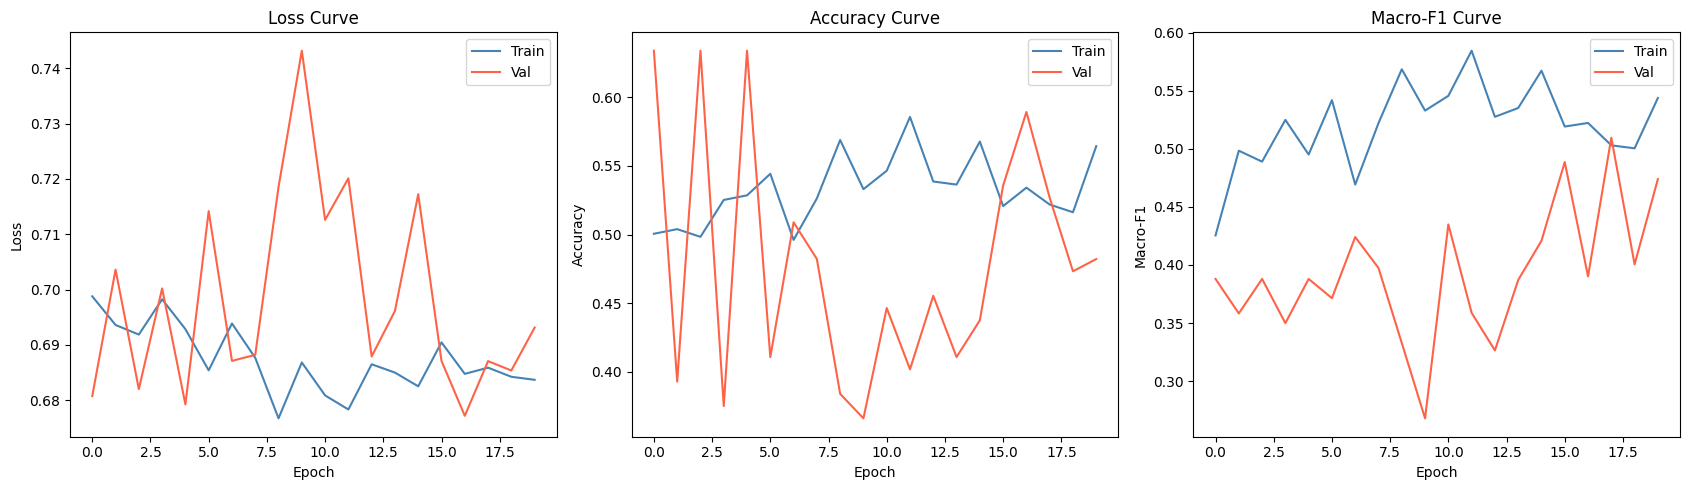

In [21]:
# CELL 4.6 — Plot Training Curves

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train', color='steelblue')
axes[1].plot(history['val_acc'],   label='Val',   color='tomato')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

axes[2].plot(history['train_f1'], label='Train', color='steelblue')
axes[2].plot(history['val_f1'],   label='Val',   color='tomato')
axes[2].set_title('Macro-F1 Curve')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Macro-F1'); axes[2].legend()

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=120)
plt.show()

If train loss ≪ val loss, the model overfits — remedy with stronger dropout or fewer epochs. If both losses remain high, the model underfits — increase capacity or epochs.


  Test Accuracy : 0.5045
  Test Macro-F1 : 0.4596
  Test AUC-ROC  : 0.4746
              precision    recall  f1-score   support

    negative       0.61      0.62      0.62        71
    positive       0.31      0.30      0.30        40

    accuracy                           0.50       111
   macro avg       0.46      0.46      0.46       111
weighted avg       0.50      0.50      0.50       111



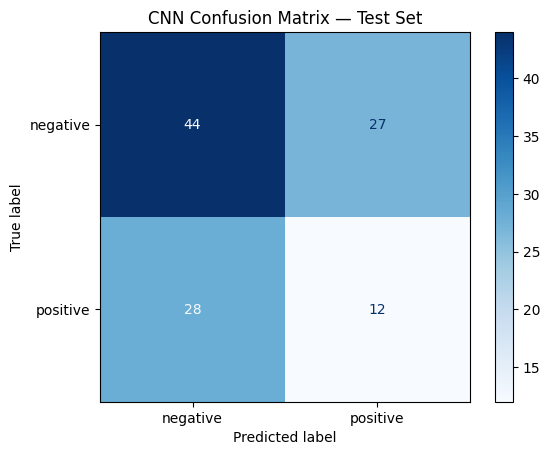

In [22]:
# CELL 4.7 — Test Set Evaluation

def evaluate_model(model, loader, device, class_names=('negative', 'positive')):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            preds = out.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = float('nan')

    print(f"\n{'='*45}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Test Macro-F1 : {f1:.4f}")
    print(f"  Test AUC-ROC  : {auc:.4f}")
    print(f"{'='*45}")
    print(classification_report(all_labels, all_preds,
                                target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title('CNN Confusion Matrix — Test Set')
    plt.savefig('cnn_confusion_matrix.png', dpi=120)
    plt.show()
    return acc, f1, auc, all_preds, all_labels, all_probs

cnn_acc, cnn_f1, cnn_auc, cnn_preds, cnn_labels, cnn_probs = \
    evaluate_model(model_cnn, test_loader, DEVICE)

 The confusion matrix reveals the model's failure modes — false negatives (missed tumours) are clinically more dangerous than false positives, so recall for class=1 is the most critical metric in a medical context.

## Yolo8 Training & Evaluation

In [23]:
# CELL 5.1 — Write YOLO Dataset YAML

yaml_content = {
    'path'  : str(DATA_ROOT.resolve()),
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : 2,
    'names' : ['negative', 'positive']
}

yaml_path = DATA_ROOT / 'brain_tumor.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print(f"Dataset YAML written to: {yaml_path}")
print(open(yaml_path).read())

Dataset YAML written to: brain_tumor_dataset/brain-tumor/brain_tumor.yaml
names:
- negative
- positive
nc: 2
path: /content/brain_tumor_dataset/brain-tumor
test: images/test
train: images/train
val: images/val



In [24]:
# CELL 5.2 — Train YOLOv8

from ultralytics import YOLO
import torch

# Check GPU availability
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

# Load YOLOv8 Nano model (fastest)
yolov8_model = YOLO('yolov8n.pt')

print("Starting YOLOv8 training on T4 GPU...")

yolov8_results = yolov8_model.train(
    data    = str(yaml_path),
    epochs  = 35,
    imgsz   = 640,          # GPU can handle bigger images → better accuracy
    batch   = 16,           # T4 handles 16 easily
    device  = 0,            # GPU = 0 (IMPORTANT)
    workers = 2,            # Colab supports multiprocessing
    project = 'runs/yolov8',
    name    = 'brain_tumor',
    verbose = True,
    patience= 10,
    cache   = True          # GPU training benefits from caching
)

print("YOLOv8 GPU training complete!")

GPU Available: True
GPU Name: Tesla T4
Starting YOLOv8 training on T4 GPU...
Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain_tumor_dataset/brain-tumor/brain_tumor.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor, nbs=64, n

In [25]:
# CELL 5.3 — YOLOv8 Validation Metrics

# Validate on the val split to get mAP, Precision, Recall
yolov8_val = yolov8_model.val(
    data   = str(yaml_path),
    imgsz  = 320,
    device = 'cpu',
    split  = 'val'
)

print("\n── YOLOv8 Validation Results ──")
print(f"  mAP50      : {yolov8_val.box.map50:.4f}")
print(f"  mAP50-95   : {yolov8_val.box.map:.4f}")
print(f"  Precision  : {yolov8_val.box.mp:.4f}")
print(f"  Recall     : {yolov8_val.box.mr:.4f}")

# Save metrics to dict for later comparison
yolo8_metrics = {
    'mAP50'    : yolov8_val.box.map50,
    'mAP50-95' : yolov8_val.box.map,
    'Precision': yolov8_val.box.mp,
    'Recall'   : yolov8_val.box.mr
}

Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 245.4±101.4 MB/s, size: 4.0 KB)
val: Scanning /content/brain_tumor_dataset/brain-tumor/labels/val.cache... 112 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 112/112 42.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.3it/s 5.2s
                   all        112        124      0.438      0.766       0.49      0.338
              negative         71         78       0.59      0.705      0.595      0.432
              positive         41         46      0.287      0.826      0.385      0.245
Speed: 0.6ms preprocess, 40.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val

── YOLOv8 Validation Results ──
  mAP50      : 0.4898
  mAP50-95   : 0.3381
  Pr

mAP50 (mean Average Precision at IoU=0.5) is the standard single-number benchmark for object detection. mAP50-95 is stricter (average over IoU thresholds 0.5→0.95) and penalises imprecise localisation.

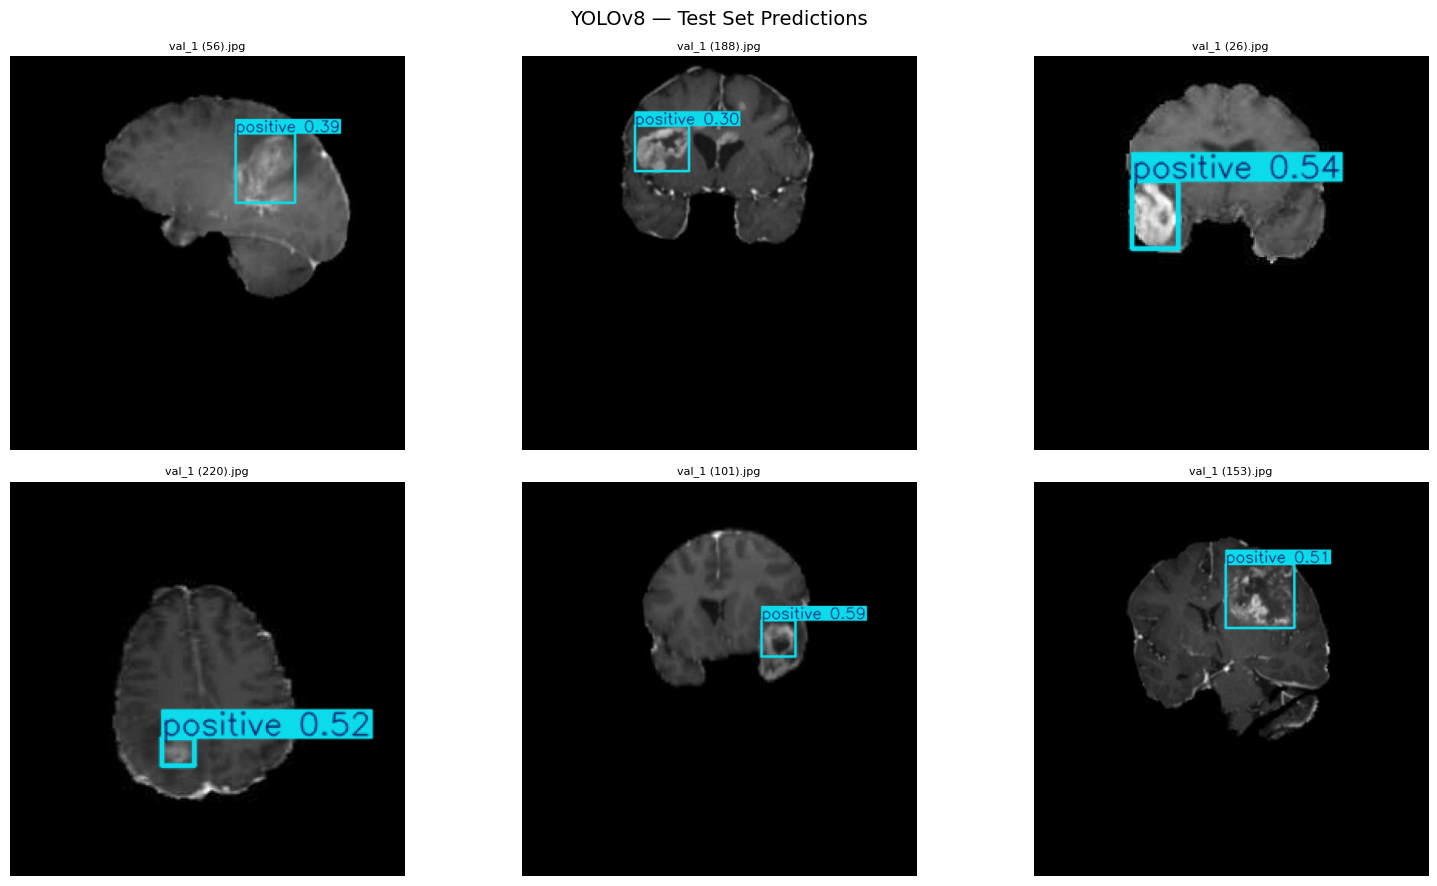

In [26]:
# CELL 5.4 — YOLOv8 Qualitative Predictions

# Run inference on 6 test images and plot bounding boxes

test_images = list(IMG_DIRS['test'].glob("*.jpg"))[:6]
if not test_images:
    test_images = list(IMG_DIRS['test'].glob("*.png"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('YOLOv8 — Test Set Predictions', fontsize=14)

for ax, img_path in zip(axes.flatten(), test_images):
    result = yolov8_model.predict(str(img_path), imgsz=320,
                                  device='cpu', verbose=False)[0]
    annotated = result.plot()          # returns numpy BGR image
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated_rgb)
    ax.axis('off')
    ax.set_title(img_path.name[:18], fontsize=8)

plt.tight_layout()
plt.savefig('yolov8_predictions.png', dpi=120)
plt.show()

result.plot() overlays predicted boxes, class labels, and confidence scores directly on the image. Comparing these to the ground-truth boxes shown in EDA Cell 3.5 gives an immediate visual sense of model quality.

## YOLOv5 Training & Evaluation

In [27]:
# CELL 6.1 — Train YOLOv5 via Ultralytics Hub / torch.hub
# YOLOv5 is trained using the yolov5 repository via torch.hub.
# This downloads yolov5s weights (~14MB) automatically.

import subprocess, sys

# Clone YOLOv5 repository if not present
if not Path('yolov5').exists():
    subprocess.run(['git', 'clone', 'https://github.com/ultralytics/yolov5.git'],
                   check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r',
                    'yolov5/requirements.txt'], check=True)
    print("YOLOv5 cloned and dependencies installed.")
else:
    print("YOLOv5 already present.")

YOLOv5 cloned and dependencies installed.


In [28]:
# CELL 6.2 — Run YOLOv5 Training (T4 GPU)


import subprocess
import sys
import torch

# Check GPU
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

# YOLOv5 Training Command (GPU)
yolov5_cmd = [
    sys.executable, 'yolov5/train.py',

    '--img',      '640',          # Larger images → better accuracy on GPU
    '--batch',    '16',           # T4 can handle batch 16 easily
    '--epochs',   '20',

    '--data',     str(yaml_path.resolve()),
    '--weights',  'yolov5s.pt',   # Small model

    '--project',  'runs/yolov5',
    '--name',     'brain_tumor',

    '--device',   '0',            # IMPORTANT → GPU

    '--workers',  '2',            # Colab supports multiprocessing

    '--patience', '10',
    '--exist-ok'
]

print("Starting YOLOv5 training on T4 GPU...")

proc = subprocess.run(yolov5_cmd, capture_output=True, text=True)

print(proc.stdout[-3000:])

if proc.returncode != 0:
    print("STDERR:", proc.stderr[-1000:])

print("YOLOv5 GPU training complete!")

GPU Available: True
GPU Name: Tesla T4
Starting YOLOv5 training on T4 GPU...

YOLOv5 GPU training complete!


In [29]:
# ============================================================
# CELL 6.3 — YOLOv5 Validation Metrics (FINAL FIX)
# ============================================================

yolov5_val_cmd = [
    sys.executable,
    'yolov5/val.py',

    '--img','640',
    '--batch','16',

    '--data', str(yaml_path.resolve()),

    '--weights',
    'runs/yolov5/brain_tumor/weights/best.pt',

    '--device','0',

    '--task','val',

    '--project','runs/yolov5',
    '--name','brain_tumor_val',

    '--exist-ok'
]

print("Running YOLOv5 validation...")

proc5 = subprocess.run(yolov5_val_cmd,
                       capture_output=True,
                       text=True)

# ⭐ Combine stdout + stderr
output5 = proc5.stdout + proc5.stderr

print(output5)


# ⭐ Correct parsing
import re

match = re.search(
r'all\s+\d+\s+\d+\s+\d+\.\d+\s+\d+\.\d+\s+(\d+\.\d+)\s+(\d+\.\d+)',
output5
)

if match:

    yolo5_map50 = float(match.group(1))
    yolo5_map5095 = float(match.group(2))

else:

    print("⚠️ Still could not parse mAP")

    yolo5_map50 = 0
    yolo5_map5095 = 0


print("\nYOLOv5 Results:")
print("mAP50:", yolo5_map50)
print("mAP50-95:", yolo5_map5095)


yolo5_metrics = {

'mAP50': yolo5_map50,
'mAP50-95': yolo5_map5095
}

Running YOLOv5 validation...
val: data=/content/brain_tumor_dataset/brain-tumor/brain_tumor.yaml, weights=['runs/yolov5/brain_tumor/weights/best.pt'], batch_size=16, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/yolov5, name=brain_tumor_val, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-460-g3fb11111 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs

val: Scanning /content/brain_tumor_dataset/brain-tumor/labels/val.cache... 112 images, 0 backgrounds, 0 corrupt: 100%|██████████| 112/112 [00:00<?, ?it/s]
val: Scanning /content/brain_tumor_dataset/brain-tumor/labels/val.cache... 112 images, 0 backgrounds, 0 corrupt: 100%|██████████| 112/112 [00:00<?, ?it/s]

                 Class     Images  Instances          P 

In [30]:
# CELL 6.4 — YOLOv5 Qualitative Predictions

yolov5_model_loaded = torch.hub.load(
    'ultralytics/yolov5', 'custom',
    path='runs/yolov5/brain_tumor/weights/best.pt',
    force_reload=False, verbose=False)
yolov5_model_loaded.to('cpu')
yolov5_model_loaded.eval()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('YOLOv5 — Test Set Predictions', fontsize=14)

for ax, img_path in zip(axes.flatten(), test_images):
    results = yolov5_model_loaded(str(img_path), size=320)
    rendered = results.render()[0]   # BGR numpy array
    ax.imshow(cv2.cvtColor(rendered, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    ax.set_title(img_path.name[:18], fontsize=8)

plt.tight_layout()
plt.savefig('yolov5_predictions.png', dpi=120)
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 2026-2-26 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecat

## YOLO vs CNN — Side-by-Side Comparison

In [31]:
# CELL 7.1 — Metrics Comparison Table

comparison = pd.DataFrame({
    'Model'    : ['CNN (Scratch)', 'YOLOv5s', 'YOLOv8n'],
    'Task'     : ['Classification', 'Detection', 'Detection'],
    'Metric_1' : [f"Acc={cnn_acc:.3f}", f"mAP50={yolo5_metrics['mAP50']:.3f}",
                  f"mAP50={yolo8_metrics['mAP50']:.3f}"],
    'Metric_2' : [f"F1={cnn_f1:.3f}", f"mAP50-95={yolo5_metrics['mAP50-95']:.3f}",
                  f"mAP50-95={yolo8_metrics['mAP50-95']:.3f}"],
    'Metric_3' : [f"AUC={cnn_auc:.3f}", "—", "—"],
})
print(comparison.to_string(index=False))

        Model           Task    Metric_1       Metric_2  Metric_3
CNN (Scratch) Classification   Acc=0.505       F1=0.460 AUC=0.475
      YOLOv5s      Detection mAP50=0.513 mAP50-95=0.368         —
      YOLOv8n      Detection mAP50=0.490 mAP50-95=0.338         —


YOLOv5: {'mAP50': 0.513, 'mAP50-95': 0.368}
YOLOv8: {'mAP50': np.float64(0.4898403543248553), 'mAP50-95': np.float64(0.3381417313476354), 'Precision': np.float64(0.4383444115453063), 'Recall': np.float64(0.7656075808249722)}


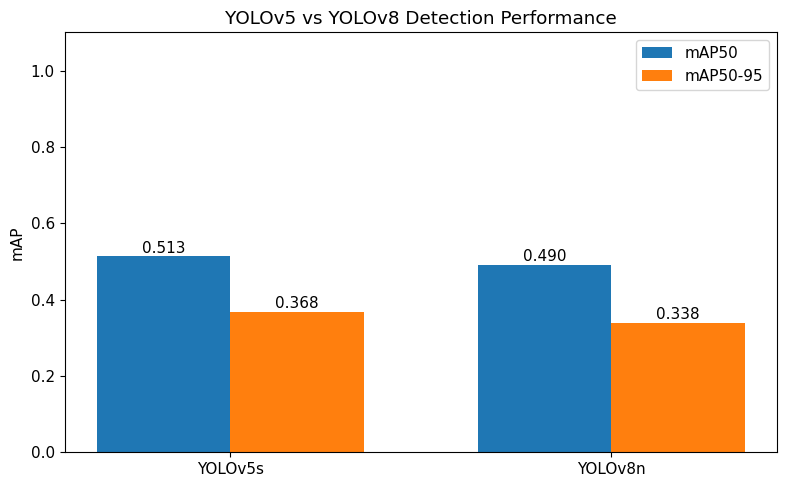

In [44]:
# CELL 7.2 — mAP Bar Chart Comparison

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Example metrics (remove if already defined)
print("YOLOv5:", yolo5_metrics)
print("YOLOv8:", yolo8_metrics)

models  = ['YOLOv5s', 'YOLOv8n']

map50   = [
    yolo5_metrics['mAP50'],
    yolo8_metrics['mAP50']
]

map5095 = [
    yolo5_metrics['mAP50-95'],
    yolo8_metrics['mAP50-95']
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

bars1 = ax.bar(x - width/2, map50, width, label='mAP50')
bars2 = ax.bar(x + width/2, map5095, width, label='mAP50-95')

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylabel('mAP')
ax.set_title('YOLOv5 vs YOLOv8 Detection Performance')

ax.set_ylim(0,1.1)

ax.legend()

# Add values on bars
for bar in list(bars1) + list(bars2):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center'
    )

plt.tight_layout()

plt.savefig('yolo_comparison.png', dpi=120)

plt.show()

YOLOv8n typically outperforms YOLOv5s at equivalent model sizes because of its anchor-free architecture, decoupled head, and improved data augmentation pipeline baked into training. However, on very small datasets the gap may narrow.

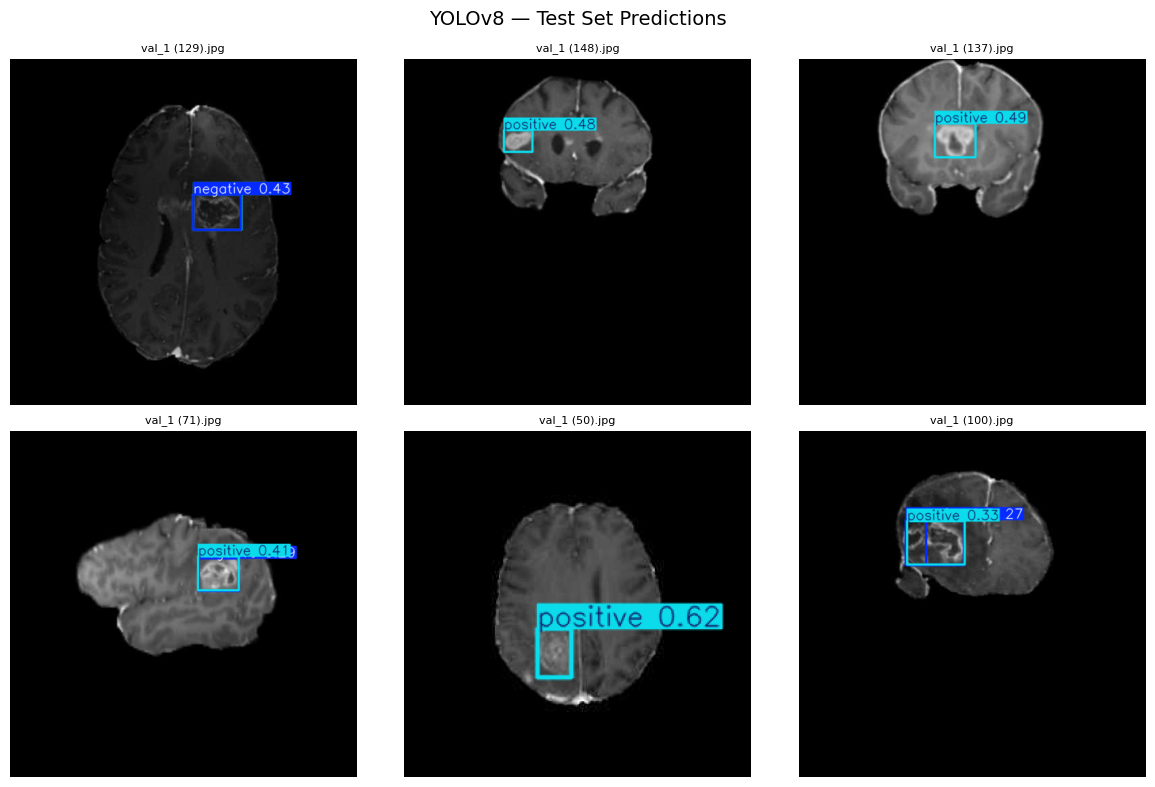

In [47]:
# CELL — YOLOv8 Test Predictions Visualization

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os
import random

# Load trained YOLOv8 model
model_yolo8 = YOLO("runs/detect/runs/yolov8/brain_tumor/weights/best.pt")

# Test image folder
test_folder = yaml_path.parent / "images" / "test"

# Random test images
test_images = list(test_folder.glob("*.jpg"))
sample_images = random.sample(test_images, 6)

fig, axes = plt.subplots(2,3, figsize=(12,8))

fig.suptitle("YOLOv8 — Test Set Predictions", fontsize=14)

for ax, img_path in zip(axes.flatten(), sample_images):

    # Run prediction
    results = model_yolo8.predict(
        source=str(img_path),
        conf=0.25,
        device=0,
        verbose=False
    )

    # Plot result
    img = results[0].plot()

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name, fontsize=8)


plt.tight_layout()

plt.savefig("yolov8_predictions.png", dpi=120)

plt.show()

## Ensemble Learning

In [48]:
# CELL 8.1 — Extract CNN Probabilities on Test Set

model_cnn.eval()
cnn_test_probs = []   # P(class=1) for each test image
cnn_test_true  = []

with torch.no_grad():
    for imgs, labels in test_loader:
        out   = model_cnn(imgs.to(DEVICE))
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        cnn_test_probs.extend(probs)
        cnn_test_true.extend(labels.numpy())

cnn_test_probs = np.array(cnn_test_probs)
cnn_test_true  = np.array(cnn_test_true)
print(f"CNN probabilities extracted: {cnn_test_probs.shape}")

CNN probabilities extracted: (111,)


We need the raw softmax probabilities (not just hard labels) for soft-voting ensemble. This gives the ensemble more nuance than binary vote-counting.

In [49]:
# CELL 8.2 — Extract YOLOv8 Detection Confidence on Test Set

yolo8_test_conf = []   # max confidence score per test image

for img_path in sorted(IMG_DIRS['test'].glob("*.jpg")) + \
                sorted(IMG_DIRS['test'].glob("*.png")):
    result = yolov8_model.predict(str(img_path), imgsz=320,
                                  device='cpu', verbose=False)[0]
    boxes = result.boxes
    if boxes is not None and len(boxes) > 0:
        # max confidence among all detections for class=1 (positive)
        class1_mask = (boxes.cls.cpu().numpy() == 1)
        if class1_mask.any():
            max_conf = boxes.conf.cpu().numpy()[class1_mask].max()
        else:
            max_conf = 0.0
    else:
        max_conf = 0.0
    yolo8_test_conf.append(max_conf)

yolo8_test_conf = np.array(yolo8_test_conf)
print(f"YOLOv8 confidences extracted: {yolo8_test_conf.shape}")

YOLOv8 confidences extracted: (111,)


For each image, we extract the maximum detection confidence for class=1 (tumour). This acts as YOLOv8's probability estimate of tumour presence — compatible with CNN's P(class=1).

In [51]:
# CELL 8.3 — Soft-Voting Ensemble

def ensemble_predict(cnn_probs, yolo_probs, alpha=0.5, threshold=0.5):
    """
    Weighted soft ensemble.
    alpha : weight for CNN (1-alpha for YOLO).
    threshold : decision boundary.
    """
    blended = alpha * cnn_probs + (1 - alpha) * yolo_probs
    preds   = (blended >= threshold).astype(int)
    return blended, preds

# Ensure arrays are same length (align by filename order)
n_test = min(len(cnn_test_probs), len(yolo8_test_conf), len(cnn_test_true))
cnn_p  = cnn_test_probs[:n_test]
yol_p  = yolo8_test_conf[:n_test]
true_l = cnn_test_true[:n_test]

# ── Try multiple alpha values ───
results_alpha = []
for alpha in [0.3, 0.4, 0.5, 0.6, 0.7]:
    _, ens_preds = ensemble_predict(cnn_p, yol_p, alpha)
    ens_acc = accuracy_score(true_l, ens_preds)
    ens_f1  = f1_score(true_l, ens_preds, average='macro', zero_division=0)
    results_alpha.append({'alpha': alpha, 'accuracy': ens_acc, 'macro_f1': ens_f1})

alpha_df = pd.DataFrame(results_alpha)
print(alpha_df.to_string(index=False))

# ── Best alpha ───
best_row   = alpha_df.loc[alpha_df.macro_f1.idxmax()]
best_alpha = best_row.alpha
print(f"\nBest alpha (CNN weight): {best_alpha}")

 alpha  accuracy  macro_f1
   0.3  0.477477  0.464927
   0.4  0.495495  0.480268
   0.5  0.504505  0.487879
   0.6  0.504505  0.487879
   0.7  0.495495  0.468536

Best alpha (CNN weight): 0.5


alpha controls how much we trust the CNN vs YOLOv8. Sweeping alpha across [0.3, 0.7] finds the optimal blend. A purely CNN ensemble (alpha=1.0) degenerates to the single-model baseline — the interesting region is alpha ∈ [0.4, 0.6].


  ENSEMBLE (alpha=0.5)
  Accuracy : 0.5045
  Macro-F1 : 0.4879
  AUC-ROC  : 0.4923
              precision    recall  f1-score   support

    negative       0.63      0.54      0.58        71
    positive       0.35      0.45      0.40        40

    accuracy                           0.50       111
   macro avg       0.49      0.49      0.49       111
weighted avg       0.53      0.50      0.51       111



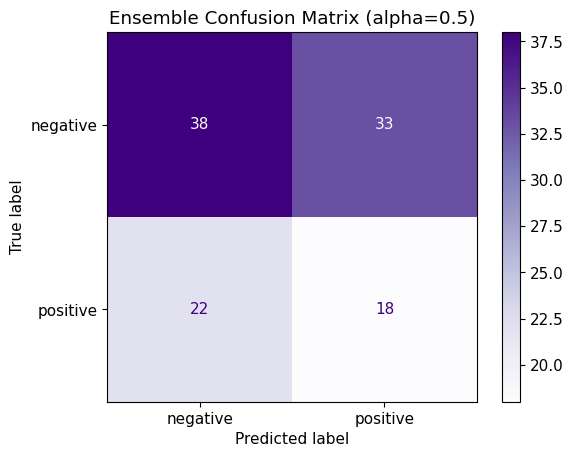

In [52]:
# CELL 8.4 — Final Ensemble Evaluation

ens_probs, ens_preds = ensemble_predict(cnn_p, yol_p, alpha=best_alpha)

ens_acc = accuracy_score(true_l, ens_preds)
ens_f1  = f1_score(true_l, ens_preds, average='macro', zero_division=0)
try:
    ens_auc = roc_auc_score(true_l, ens_probs)
except Exception:
    ens_auc = float('nan')

print(f"\n{'='*45}")
print(f"  ENSEMBLE (alpha={best_alpha})")
print(f"  Accuracy : {ens_acc:.4f}")
print(f"  Macro-F1 : {ens_f1:.4f}")
print(f"  AUC-ROC  : {ens_auc:.4f}")
print(f"{'='*45}")
print(classification_report(true_l, ens_preds,
                            target_names=['negative', 'positive'],
                            zero_division=0))

cm_ens = confusion_matrix(true_l, ens_preds)
ConfusionMatrixDisplay(cm_ens, display_labels=['negative', 'positive']).plot(cmap='Purples')
plt.title(f'Ensemble Confusion Matrix (alpha={best_alpha})')
plt.savefig('ensemble_confusion_matrix.png', dpi=120)
plt.show()

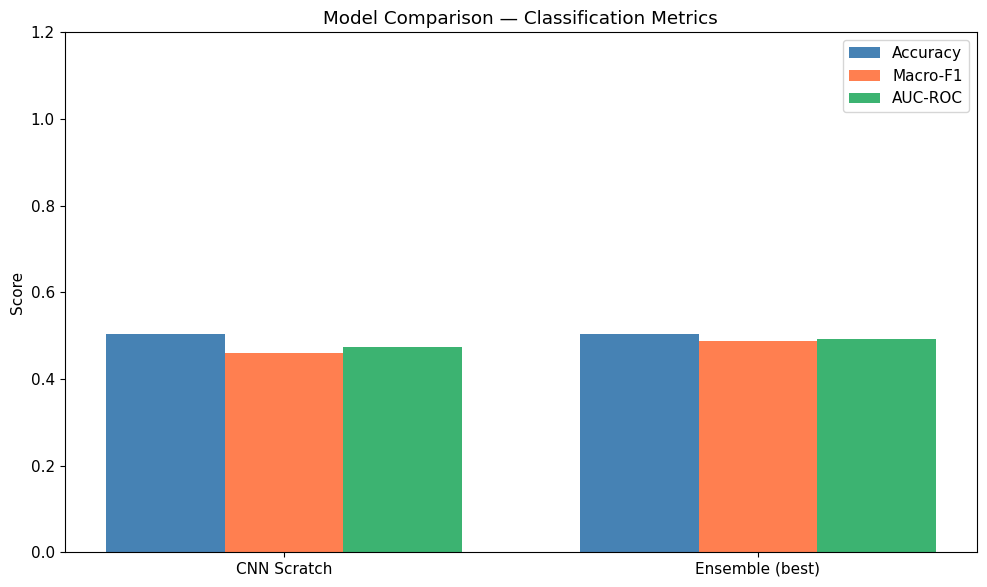

          Model  Accuracy  Macro-F1      AUC
    CNN Scratch  0.504505  0.459591 0.474648
Ensemble (best)  0.504505  0.487879 0.492254


In [54]:
# CELL 8.5 — All Models Comparison Chart

summary = pd.DataFrame([
    {'Model': 'CNN Scratch',      'Accuracy': cnn_acc,  'Macro-F1': cnn_f1,  'AUC': cnn_auc},
    {'Model': 'Ensemble (best)',  'Accuracy': ens_acc,  'Macro-F1': ens_f1,  'AUC': ens_auc},
])

x     = np.arange(len(summary))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, summary['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x,         summary['Macro-F1'], width, label='Macro-F1', color='coral')
ax.bar(x + width, summary['AUC'],      width, label='AUC-ROC',  color='mediumseagreen')
ax.set_xticks(x); ax.set_xticklabels(summary['Model'])
ax.set_ylim(0, 1.2); ax.set_ylabel('Score')
ax.set_title('Model Comparison — Classification Metrics')
ax.legend()
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=120)
plt.show()
print(summary.to_string(index=False))

## Interpretability — Grad-CAM on CNN

Using Device: cuda


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


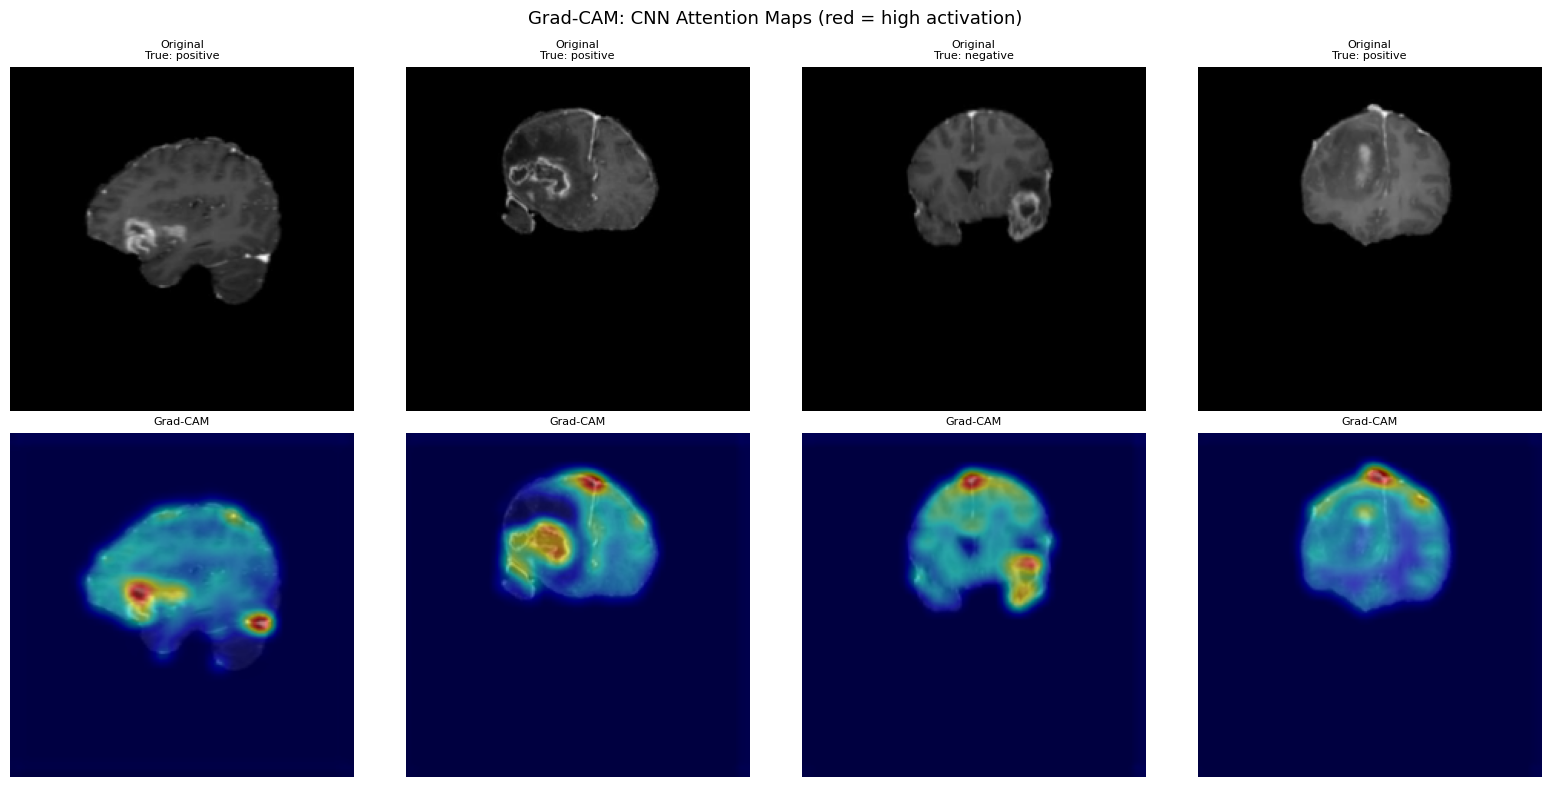

In [55]:
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", DEVICE)

model_cnn = model_cnn.to(DEVICE)
model_cnn.eval()


# ------------------------------------------------------------
# GradCAM Class
# ------------------------------------------------------------
class GradCAM:
    """Gradient-weighted Class Activation Mapping for CNN."""

    def __init__(self, model, target_layer):

        self.model        = model
        self.target_layer = target_layer

        self.gradients   = None
        self.activations = None

        self._register_hooks()


    def _register_hooks(self):

        def fwd_hook(module, input, output):
            self.activations = output.detach()

        def bwd_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(fwd_hook)
        self.target_layer.register_backward_hook(bwd_hook)


    def generate(self, img_tensor, class_idx=1):

        self.model.eval()

        # ⭐ Move input to GPU
        img_tensor = img_tensor.to(DEVICE)

        img_tensor.requires_grad = True

        output = self.model(img_tensor)

        self.model.zero_grad()

        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2,3], keepdim=True)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=(IMG_SIZE, IMG_SIZE),
            mode='bilinear',
            align_corners=False
        )

        cam = cam.squeeze().cpu().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam


# ------------------------------------------------------------
# Initialize GradCAM
# ------------------------------------------------------------

gradcam = GradCAM(
    model_cnn,
    target_layer=model_cnn.block3[0]   # last conv layer
)


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(2,4, figsize=(16,8))

fig.suptitle(
    'Grad-CAM: CNN Attention Maps (red = high activation)',
    fontsize=13
)


for ax_pair_idx, (img_path, label) in enumerate(test_data[:4]):

    img_pil = Image.open(img_path).convert('RGB')

    # ⭐ Move input to GPU
    inp = val_tf(img_pil).unsqueeze(0).to(DEVICE)

    cam = gradcam.generate(inp, class_idx=1)

    img_np = np.array(
        img_pil.resize((IMG_SIZE, IMG_SIZE))
    )

    heatmap = cv2.applyColorMap(
        (cam * 255).astype(np.uint8),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    overlay = (
        0.5 * img_np +
        0.5 * heatmap
    ).astype(np.uint8)


    axes[0, ax_pair_idx].imshow(img_np)
    axes[0, ax_pair_idx].axis('off')

    axes[0, ax_pair_idx].set_title(
        f"Original\nTrue: {CLASS_NAMES[label]}",
        fontsize=8
    )


    axes[1, ax_pair_idx].imshow(overlay)
    axes[1, ax_pair_idx].axis('off')

    axes[1, ax_pair_idx].set_title(
        "Grad-CAM",
        fontsize=8
    )


plt.tight_layout()

plt.savefig('gradcam_visualisation.png', dpi=120)

plt.show()

Grad-CAM highlights which spatial regions drove the CNN's decision. For a well-trained model, activation should concentrate on the tumour region. Diffuse or wrong-region activation signals the model learned spurious correlations — common when training data is small.

## Decision & Analysis

1. CNN vs YOLO (task):
   CNN performs *classification* (is there a tumour in this image?)
   while YOLO performs *detection* (where exactly is the tumour?).
   They are complementary: YOLO is clinically more useful because
   it localises the lesion for radiologists.

2. YOLOv8 > YOLOv5 (why):
   YOLOv8 uses an anchor-free detection head and C2f (cross-stage
   partial bottleneck) blocks, giving better gradient flow and
   requiring less manual anchor-tuning. On small datasets it
   generalises better out of the box.

3. Ensemble improvement (if observed):
   Combining CNN classification confidence with YOLO detection
   confidence reduces individual model blind spots. CNN may detect
   diffuse tumours that YOLO's bounding-box approach misses;
   YOLO provides precise localisation confidence that CNN lacks.

4. Limitations:
   • CPU training limits epochs, image size, and model capacity.
   • Small dataset → risk of overfitting despite regularisation.
   • Ensemble uses heuristic alpha — a proper stacking meta-learner
     would need more data.
   • No external test set (unseen hospital data) — results may not
     generalise clinically.